In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 200

In [3]:
df = pd.read_csv(r'C:\AICE\AICE\data\flight.csv')
df = df.drop(['Unnamed: 0'], axis=1)
df.head(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [5]:
df.describe(include='all')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [6]:
df_price = df.sort_values('price', ascending=False)
df_price.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
261377,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.50,3,123071
216096,Vistara,UK-811,Delhi,Early_Morning,two_or_more,Evening,Kolkata,Business,10.92,5,117307
215859,Vistara,UK-809,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,116562
277345,Vistara,UK-870,Hyderabad,Night,one,Afternoon,Mumbai,Business,16.42,3,115211
270999,Vistara,UK-772,Kolkata,Morning,one,Evening,Hyderabad,Business,9.50,17,114705


In [7]:
x = df['price'].agg(min='min', q25=lambda s: s.quantile(0.25), median='median', q75=lambda s: s.quantile(0.75), max='max')
display(x)

min         1105.0
q25         4783.0
median      7425.0
q75        42521.0
max       123071.0
Name: price, dtype: float64

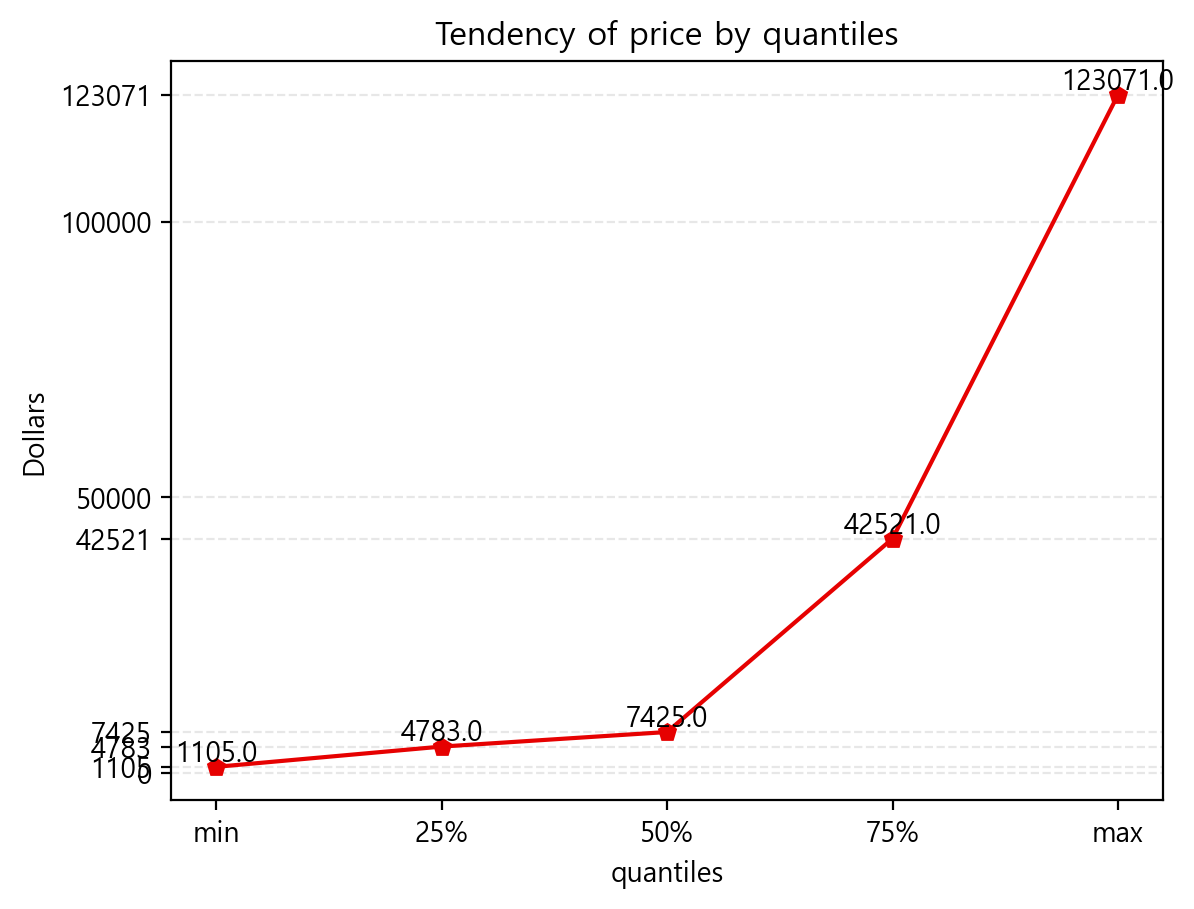

In [8]:
# plt.figure(figsize=(5, 8))
plt.plot(x.index, x, ls='-', color="#e60101", marker='p')
plt.title('Tendency of price by quantiles')
plt.xticks(x.index, labels=['min', '25%', '50%', '75%', 'max'])
plt.yticks(sorted(set(list(x.values) + [0, 50000, 100000])))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlabel('quantiles')
plt.ylabel('Dollars')
for i, v in enumerate(x.values):
    plt.text(i, v+1000, v, ha='center')

plt.show()

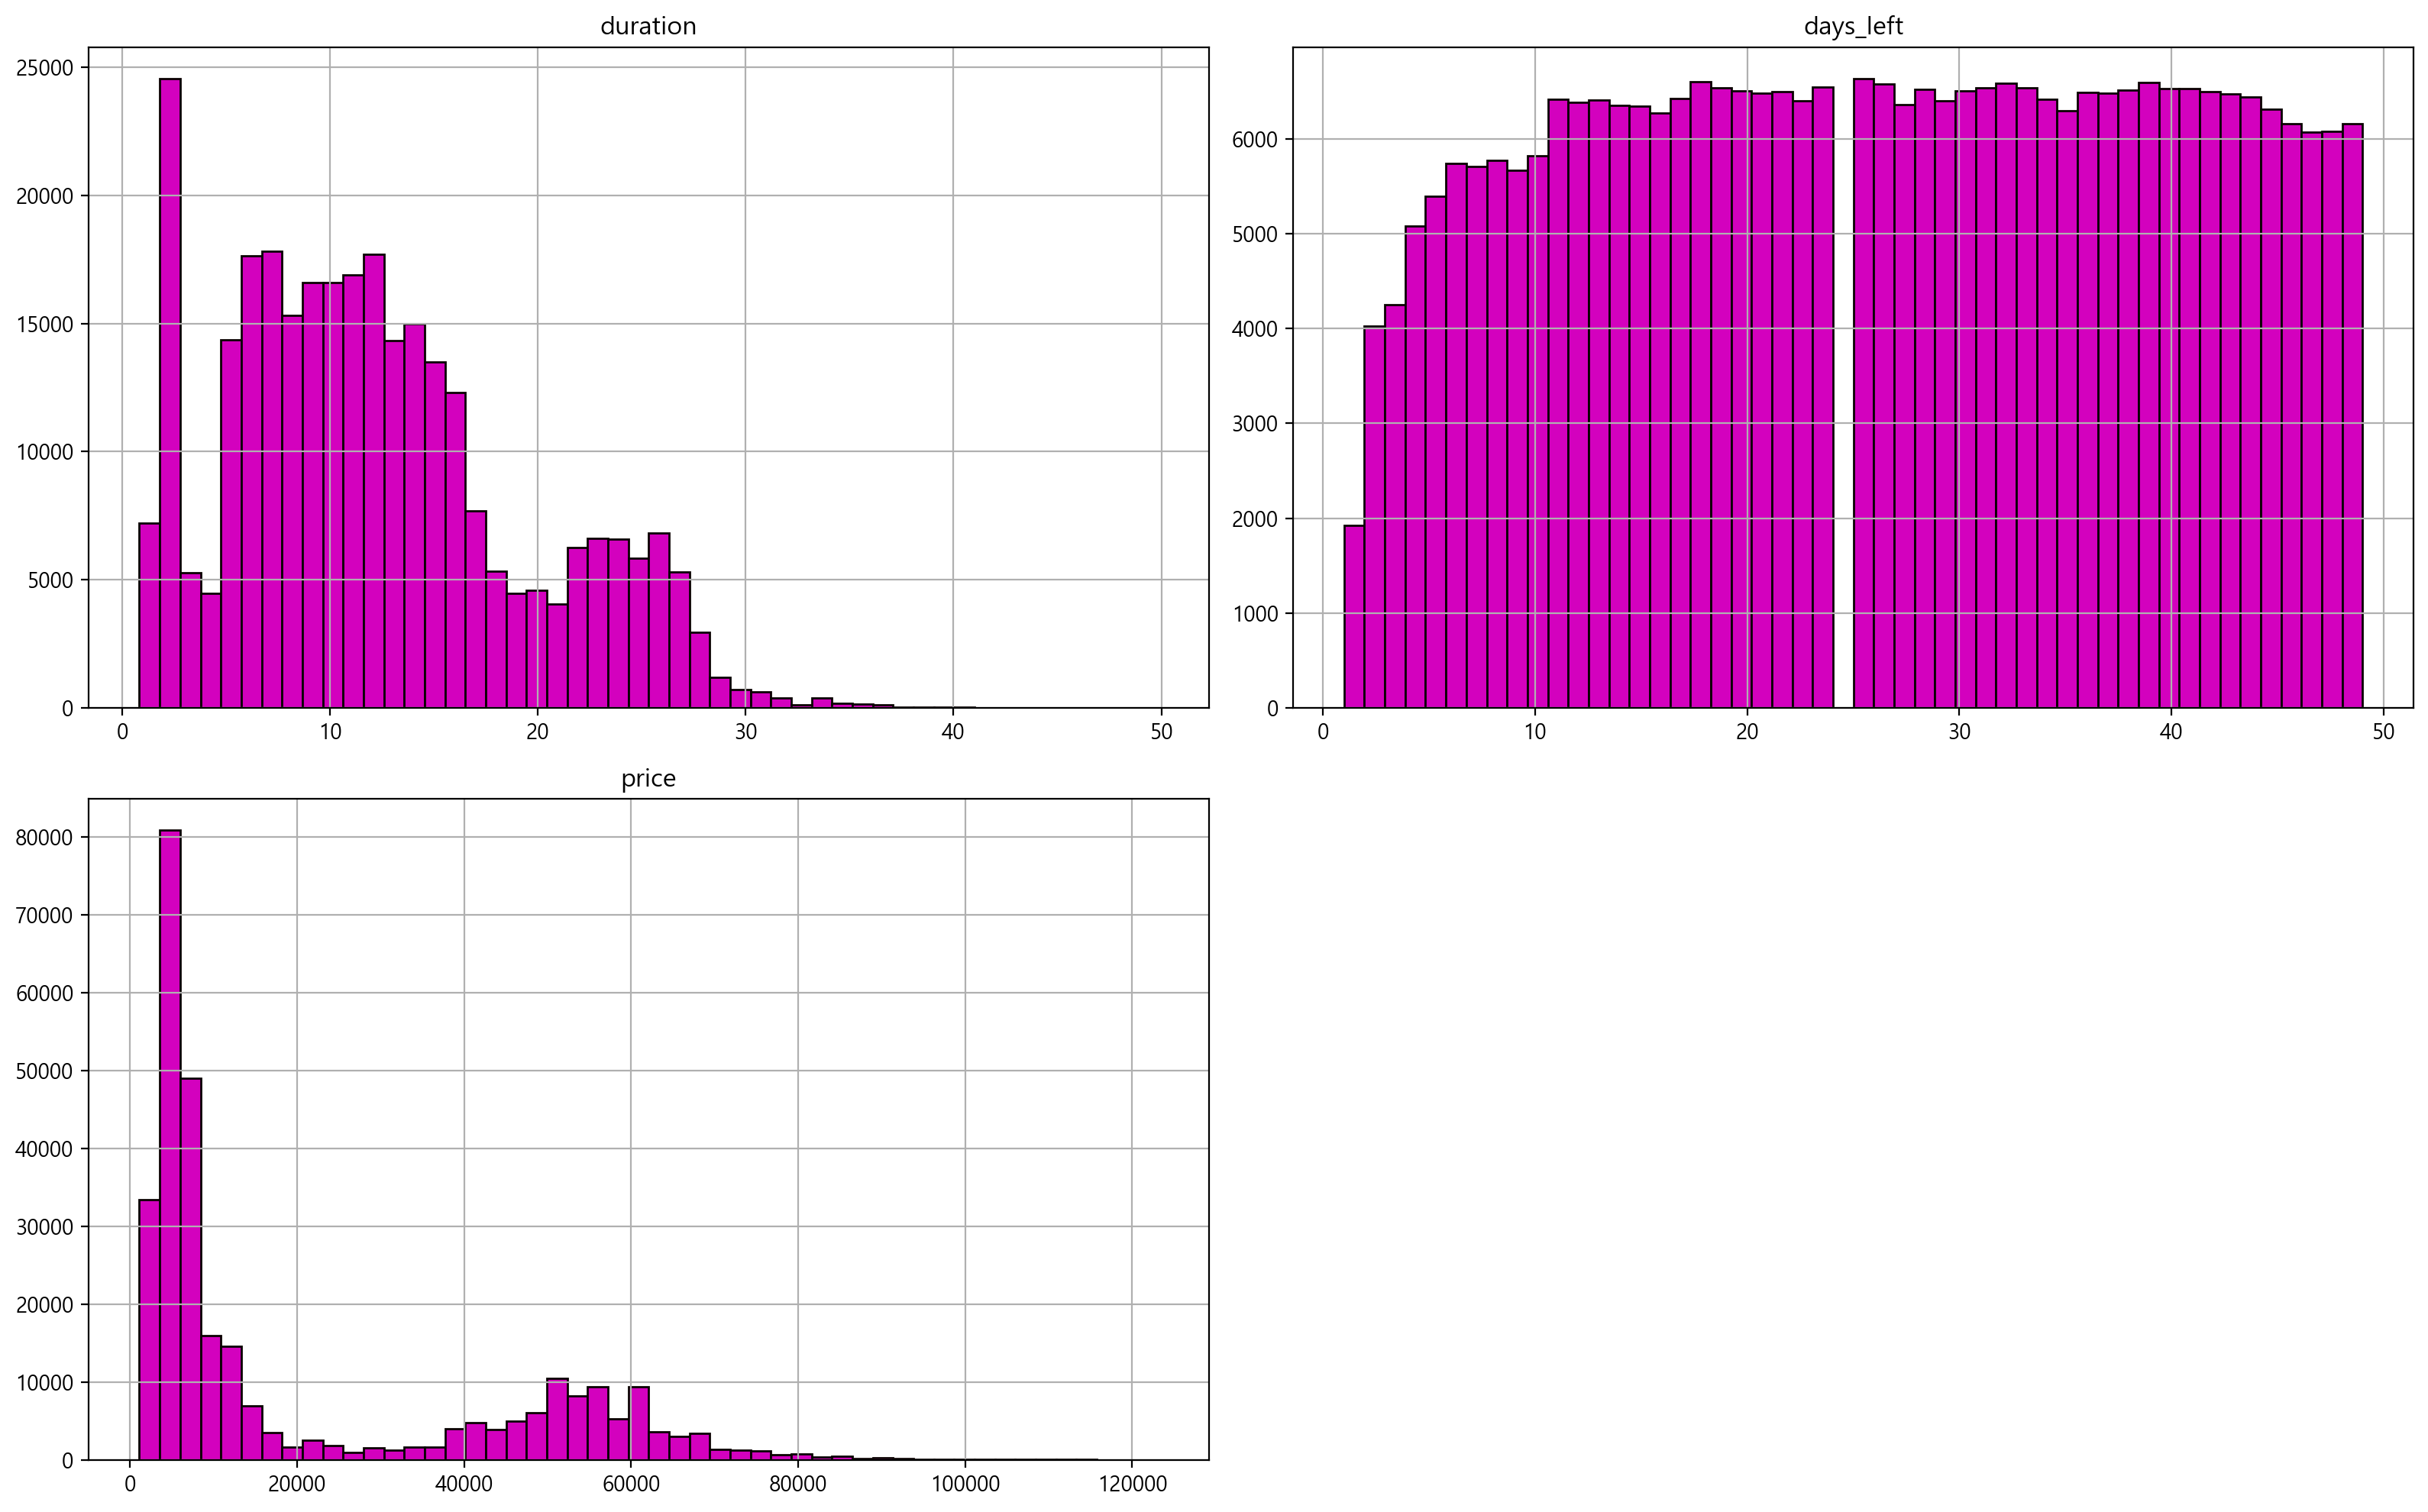

In [9]:
df.hist(bins=50, figsize=(16, 10), color="#D301BE", edgecolor="#0A0101")
plt.tight_layout()
plt.show()

In [10]:
df.describe(include='all')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


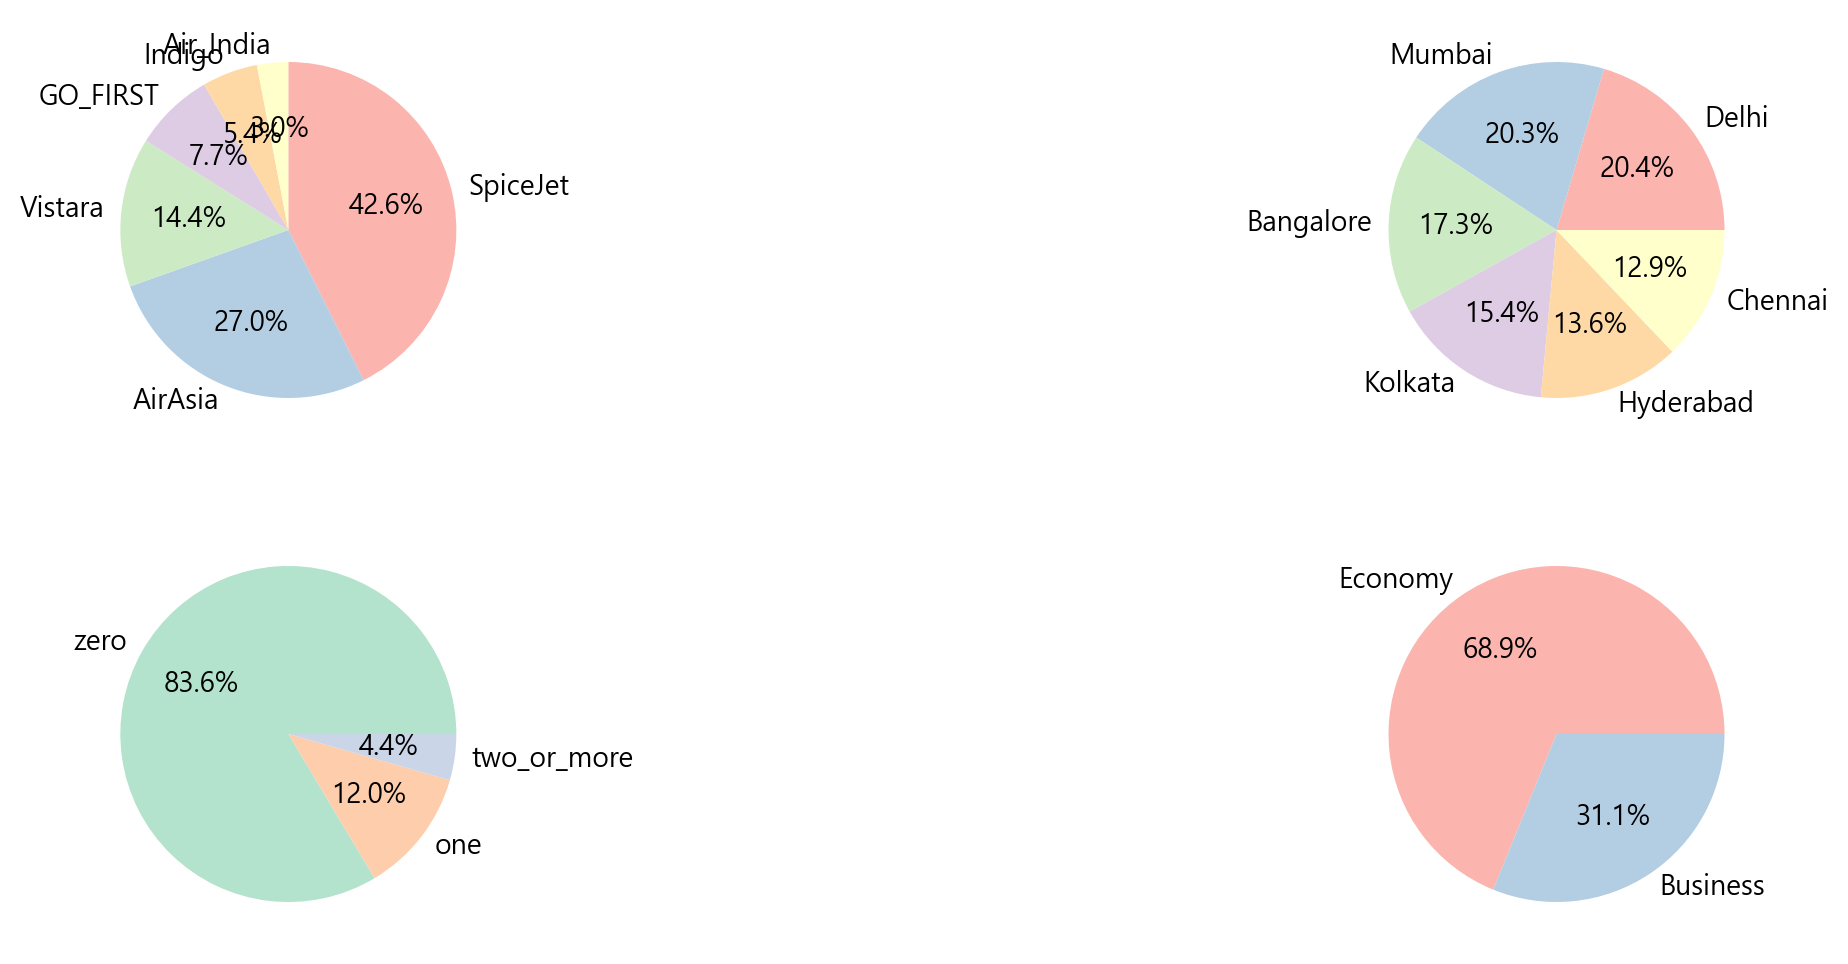

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 6))

axes[0, 0].pie(df['airline'].value_counts(), colors=plt.cm.Pastel1.colors, labels=df['airline'].unique(), autopct='%1.1f%%', startangle=90, counterclock=False)
axes[0, 1].pie(df['source_city'].value_counts(), colors=plt.cm.Pastel1.colors, labels=df['source_city'].unique(), autopct='%1.1f%%')
axes[1, 0].pie(df['stops'].value_counts(), labels=df['stops'].unique(), colors=plt.cm.Pastel2.colors, autopct='%1.1f%%')
axes[1, 1].pie(df['class'].value_counts(), labels=df['class'].unique(), colors=plt.cm.Pastel1.colors, autopct='%1.1f%%')

plt.show()

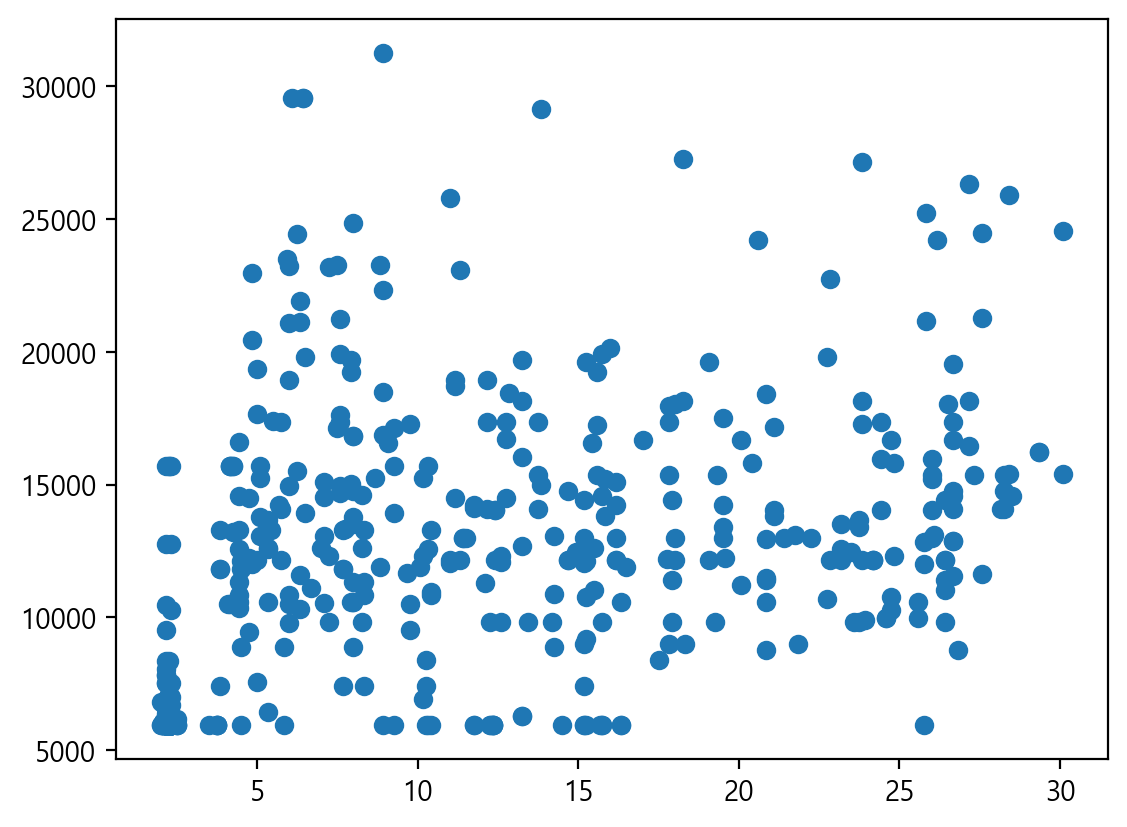

In [12]:
plt.scatter(df['duration'].head(500), df['price'].head(500))
plt.show()

           days_left     price
days_left   1.000000 -0.091949
price      -0.091949  1.000000

[[ 1.         -0.09194853]
 [-0.09194853  1.        ]]


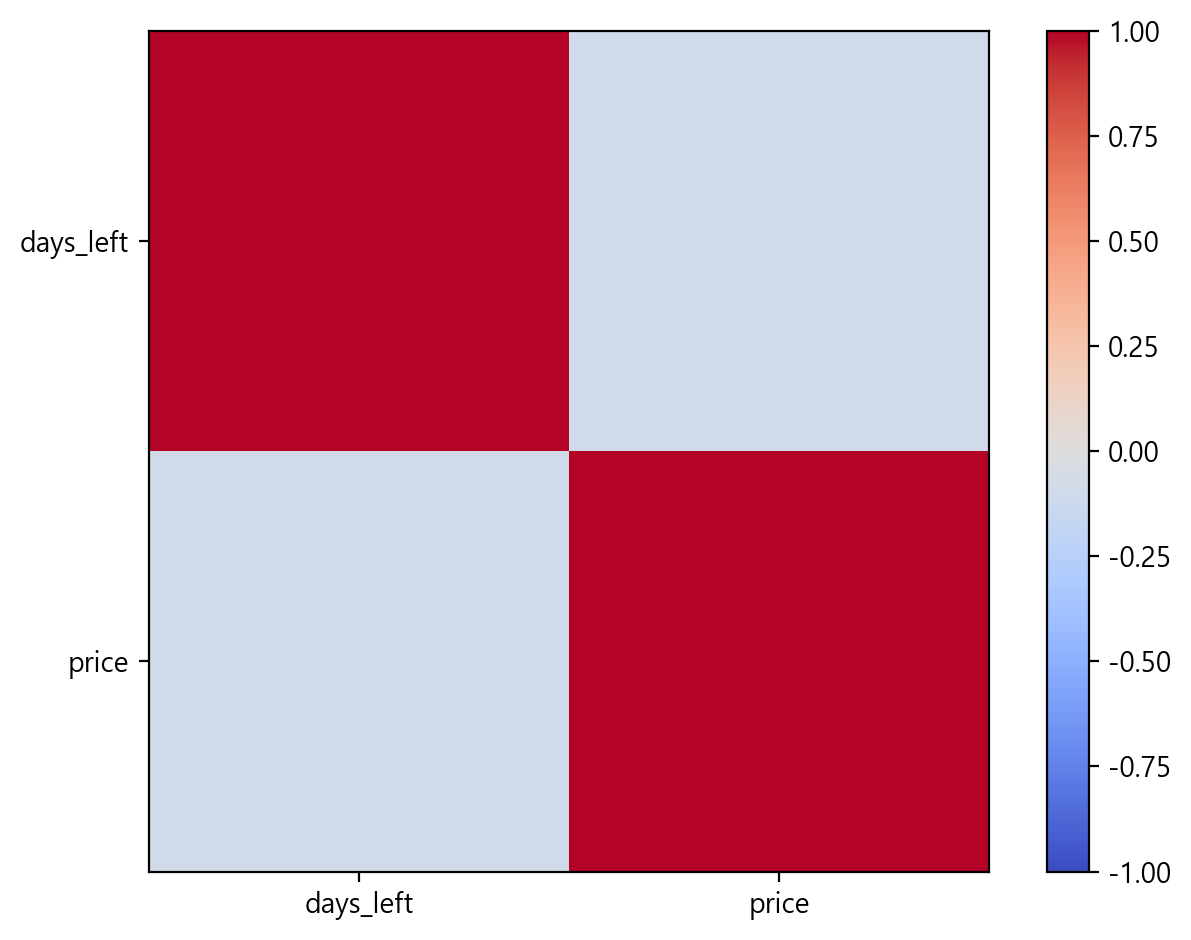

In [14]:
sub = ['days_left', 'price']
corr = df[sub].corr()
print(corr)
print()
print(corr.values)
img = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(img)
plt.xticks(range(len(corr)), sub)
plt.yticks(range(len(corr)), sub)
plt.tight_layout()

plt.show()

           days_left     price
days_left   1.000000 -0.091949
price      -0.091949  1.000000

[[ 1.         -0.09194853]
 [-0.09194853  1.        ]]


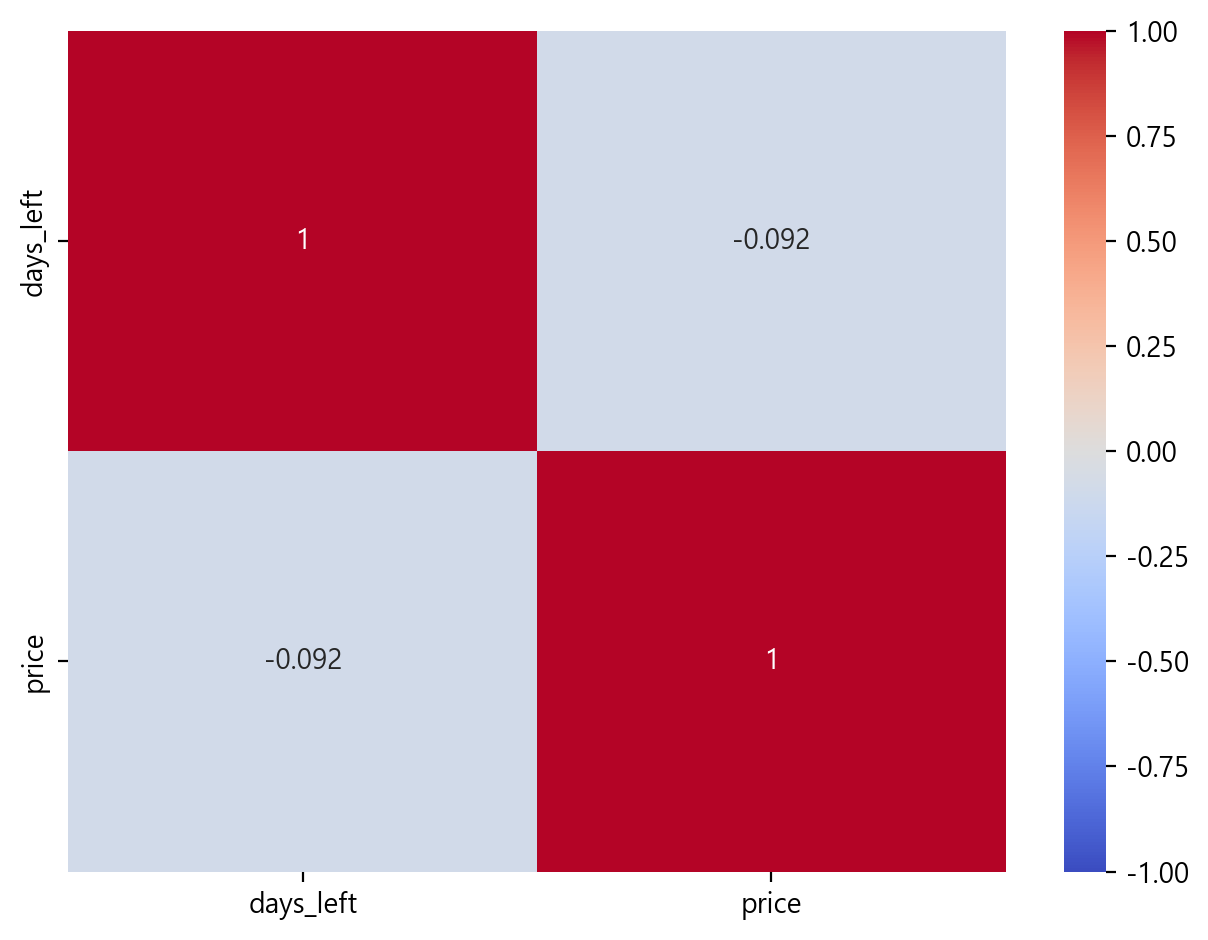

In [15]:
sub = ['days_left', 'price']

corr = df[sub].corr()

print(corr)
print()
print(corr.values)

sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

plt.tight_layout()
plt.show()